In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
import xgboost

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [75]:
data = pd.read_csv("data/train_users_2.csv")
sessions = pd.read_csv("data/sessions.csv")

In [76]:
display(data.shape, sessions.shape)

display(data.head(5))
display(sessions.head(5))


(213451, 16)

(10567737, 6)

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US


,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0


In [77]:
print("data columns:", data.columns.tolist())
print("\nSESSIONS columns:", sessions.columns.tolist())

display(data.dtypes.to_frame("dtype"))
display(sessions.dtypes.to_frame("dtype"))

data columns: ['id', 'date_account_created', 'timestamp_first_active', 'date_first_booking', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination']

SESSIONS columns: ['user_id', 'action', 'action_type', 'action_detail', 'device_type', 'secs_elapsed']


,dtype
id,object
date_account_created,object
timestamp_first_active,int64
date_first_booking,object
gender,object
age,float64
signup_method,object
signup_flow,int64
language,object
affiliate_channel,object


,dtype
user_id,object
action,object
action_type,object
action_detail,object
device_type,object
secs_elapsed,float64


In [78]:
def missing_report(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{name} - Missing columns: {len(miss)} / {df.shape[1]}")
    if len(miss):
        display(pd.DataFrame({
            "missing": miss,
            "missing_%": (miss / len(df) * 100).round(2)
        }))

missing_report(data, "data")
missing_report(sessions, "sessions")


data - Missing columns: 3 / 16


,missing,missing_%
date_first_booking,124543,58.35
age,87990,41.22
first_affiliate_tracked,6065,2.84



sessions - Missing columns: 5 / 6


,missing,missing_%
action_type,1126204,10.66
action_detail,1126204,10.66
secs_elapsed,136031,1.29
action,79626,0.75
user_id,34496,0.33


In [79]:
display(data.describe(include=[np.number]).T)
display(sessions.describe(include=[np.number]).T)

,count,mean,std,min,25%,50%,75%,max
timestamp_first_active,213451.0,2.013085e+13,9.253717e+09,2.009032e+13,2.012123e+13,2.013091e+13,2.014031e+13,2.014063e+13
age,125461.0,4.966834e+01,1.556666e+02,1.000000e+00,2.800000e+01,3.400000e+01,4.300000e+01,2.014000e+03
signup_flow,213451.0,3.267387e+00,7.637707e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e+01


,count,mean,std,min,25%,50%,75%,max
secs_elapsed,10431706.0,19405.810751,88884.243209,0.0,229.0,1147.0,8444.0,1799977.0


In [80]:
if "id" in data.columns:
    print("data.id unique:", data["id"].nunique(), " / rows:", len(data))
if "user_id" in sessions.columns:
    print("sessions.user_id unique:", sessions["user_id"].nunique(), " / rows:", len(sessions))

# how many data users have sessions?
if "id" in data.columns and "user_id" in sessions.columns:
    overlap = sessions["user_id"].isin(data["id"]).mean()
    print("Share of sessions rows whose user_id exists in data.id:", round(overlap, 4))

data.id unique: 213451  / rows: 213451
sessions.user_id unique: 135483  / rows: 10567737
Share of sessions rows whose user_id exists in data.id: 0.524


In [81]:
# =========================
# 1) Convert date columns properly
# =========================

data["date_account_created"] = pd.to_datetime(data["date_account_created"])
data["date_first_booking"] = pd.to_datetime(data["date_first_booking"], errors="coerce")

# timestamp_first_active conversion
data["timestamp_first_active"] = pd.to_datetime(
    data["timestamp_first_active"].astype(str),
    format="%Y%m%d%H%M%S"
)

print("Date conversion done.")


Date conversion done.


In [82]:
# =========================
# 2) Fix age column professionally
# =========================

# Replace impossible ages
data.loc[data["age"] < 15, "age"] = np.nan
data.loc[data["age"] > 100, "age"] = np.nan

# Also handle birth year case (1900-2014 range)
data.loc[(data["age"] > 1900) & (data["age"] < 2015), "age"] = \
    2015 - data.loc[(data["age"] > 1900) & (data["age"] < 2015), "age"]

print("Age cleaned.")


Age cleaned.


In [83]:
# =========================
# 3) Extract powerful date features
# =========================

data["dac_year"] = data["date_account_created"].dt.year
data["dac_month"] = data["date_account_created"].dt.month
data["dac_day"] = data["date_account_created"].dt.day
data["dac_weekday"] = data["date_account_created"].dt.weekday

data["tfa_year"] = data["timestamp_first_active"].dt.year
data["tfa_month"] = data["timestamp_first_active"].dt.month
data["tfa_day"] = data["timestamp_first_active"].dt.day

print("Date features created.")


Date features created.


<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='country_destination'>

Text(0.5, 1.0, 'Target Distribution')

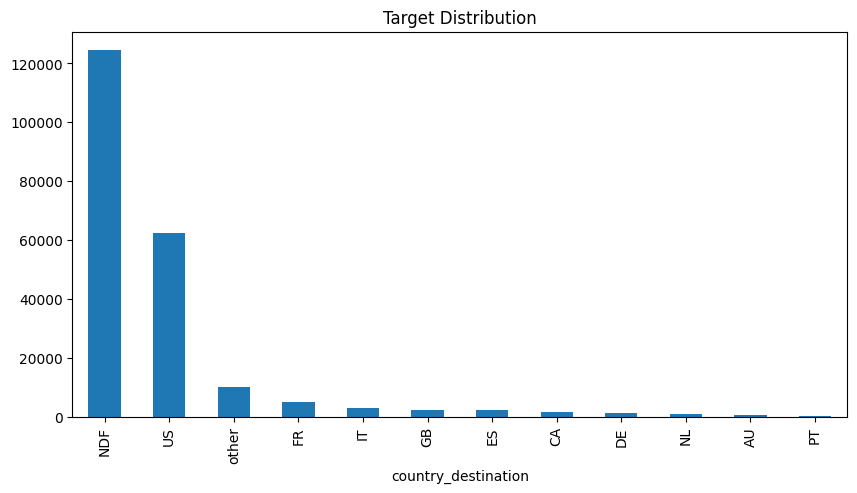

country_destination
NDF      0.583473
US       0.292226
other    0.047290
FR       0.023532
IT       0.013282
GB       0.010888
ES       0.010536
CA       0.006690
DE       0.004971
NL       0.003570
AU       0.002525
PT       0.001017
Name: proportion, dtype: float64

In [84]:
# =========================
# 4) Target Distribution (VERY IMPORTANT)
# =========================

plt.figure(figsize=(10,5))
data["country_destination"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

data["country_destination"].value_counts(normalize=True)


In [85]:
data.age.describe()

count    123059.000000
mean         36.559211
std          11.690611
min          15.000000
25%          28.000000
50%          34.000000
75%          42.000000
max         100.000000
Name: age, dtype: float64

In [86]:
# =========================
# SESSION FEATURE ENGINEERING - V2 (numeric + list features)
# =========================

print("Starting session aggregation (V2)...")

# --- 1) Clean missing values ---
sessions = sessions.copy()

cat_cols = ["action", "action_type", "action_detail", "device_type"]
for c in cat_cols:
    sessions[c] = sessions[c].fillna("unknown").astype(str)

sessions["secs_elapsed"] = sessions["secs_elapsed"].fillna(0)

# Optional: if there are rows with missing user_id, drop them (cannot aggregate)
sessions = sessions.dropna(subset=["user_id"])

# --- 2) Numeric aggregations ---
num_agg = (
    sessions.groupby("user_id")
    .agg(
        total_actions=("action", "count"),
        unique_actions=("action", "nunique"),
        unique_action_types=("action_type", "nunique"),
        unique_devices=("device_type", "nunique"),
        total_secs=("secs_elapsed", "sum"),
        mean_secs=("secs_elapsed", "mean"),
        median_secs=("secs_elapsed", "median"),
        std_secs=("secs_elapsed", "std"),
    )
    .reset_index()
)

# --- 3) List (set) features: keep the actual names ---
list_agg = (
    sessions.groupby("user_id")
    .agg(
        devices_list=("device_type", lambda x: sorted(set(x))),
        actions_list=("action", lambda x: sorted(set(x))),
        action_types_list=("action_type", lambda x: sorted(set(x))),
        action_details_list=("action_detail", lambda x: sorted(set(x))),
    )
    .reset_index()
)

# --- 4) Merge numeric + list features ---
session_agg_v2 = num_agg.merge(list_agg, on="user_id", how="left")

print("Aggregation complete (V2).")
print("Shape:", session_agg_v2.shape)

display(session_agg_v2.head())


Starting session aggregation (V2)...
Aggregation complete (V2).
Shape: (135483, 13)


,user_id,total_actions,unique_actions,unique_action_types,unique_devices,total_secs,mean_secs,median_secs,std_secs,devices_list,actions_list,action_types_list,action_details_list
0,00023iyk9l,40,14,7,2,867896.0,21697.400000,843.0,91120.246977,"[Mac Desktop, iPhone]","[ajax_refresh_subtotal, callback, confirm_emai...","[booking_request, click, data, message_post, p...","[change_trip_characteristics, confirm_email_li..."
1,0010k6l0om,63,11,6,1,586543.0,9310.206349,847.0,22598.457942,[Mac Desktop],"[ajax_refresh_subtotal, callback, custom_recom...","[-unknown-, click, data, partner_callback, unk...","[-unknown-, change_trip_characteristics, dashb..."
2,001wyh0pz8,90,10,6,1,282965.0,3144.055556,1104.0,6541.226692,[Android App Unknown Phone/Tablet],"[active, campaigns, collections, create, index...","[-unknown-, click, data, submit, unknown, view]","[-unknown-, notifications, p3, signup, unknown..."
3,0028jgx1x1,31,5,5,2,297010.0,9580.967742,489.0,17791.419521,"[-unknown-, Android Phone]","[active, create, reviews, search, show]","[-unknown-, click, data, submit, view]","[-unknown-, create_user, listing_reviews, p3, ..."
4,002qnbzfs5,789,26,8,2,6487080.0,8221.901141,498.0,58074.501758,"[-unknown-, iPhone]","[10, active, at_checkpoint, campaigns, click, ...","[-unknown-, booking_request, click, data, mess...","[-unknown-, at_checkpoint, book_it, confirm_em..."


In [87]:
print("\nSESSIONS columns:", session_agg_v2.columns.tolist())



SESSIONS columns: ['user_id', 'total_actions', 'unique_actions', 'unique_action_types', 'unique_devices', 'total_secs', 'mean_secs', 'median_secs', 'std_secs', 'devices_list', 'actions_list', 'action_types_list', 'action_details_list']


In [88]:
# =========================
# Top-K counts per user (model-friendly)
# =========================

TOPK = 10

# Top devices overall
top_devices = sessions["device_type"].value_counts().head(TOPK).index.tolist()
device_counts = (
    sessions[sessions["device_type"].isin(top_devices)]
    .groupby(["user_id", "device_type"])
    .size()
    .unstack(fill_value=0)
)
device_counts.columns = [f"device_count__{c}" for c in device_counts.columns]
device_counts = device_counts.reset_index()

# Top actions overall
top_actions = sessions["action"].value_counts().head(TOPK).index.tolist()
action_counts = (
    sessions[sessions["action"].isin(top_actions)]
    .groupby(["user_id", "action"])
    .size()
    .unstack(fill_value=0)
)
action_counts.columns = [f"action_count__{c}" for c in action_counts.columns]
action_counts = action_counts.reset_index()

# Merge into session_agg_v2
session_agg_v2 = (
    session_agg_v2
    .merge(device_counts, on="user_id", how="left")
    .merge(action_counts, on="user_id", how="left")
)

# Fill missing counts with 0
count_cols = [c for c in session_agg_v2.columns if c.startswith(("device_count__", "action_count__"))]
session_agg_v2[count_cols] = session_agg_v2[count_cols].fillna(0).astype(int)

print("Added Top-K count features.")
print("New shape:", session_agg_v2.shape)



Added Top-K count features.
New shape: (135483, 33)


In [89]:
session_agg_v2[['user_id','devices_list','actions_list']].head(3)

,user_id,devices_list,actions_list
0,00023iyk9l,"[Mac Desktop, iPhone]","[ajax_refresh_subtotal, callback, confirm_emai..."
1,0010k6l0om,[Mac Desktop],"[ajax_refresh_subtotal, callback, custom_recom..."
2,001wyh0pz8,[Android App Unknown Phone/Tablet],"[active, campaigns, collections, create, index..."


<Figure size 800x500 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Distribution of Total Actions per User')

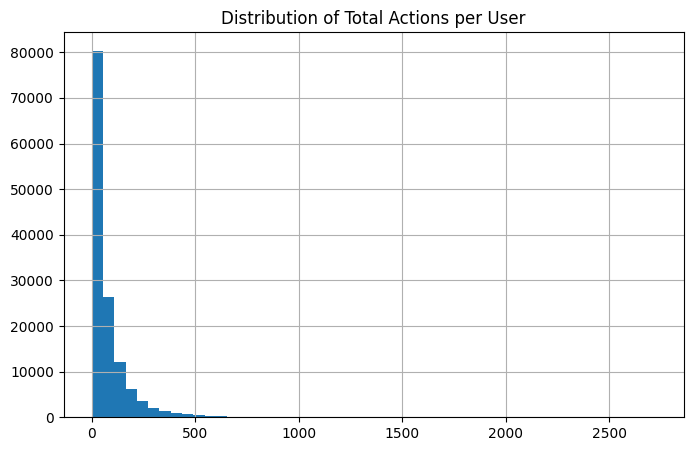

In [90]:
plt.figure(figsize=(8,5))
session_agg_v2["total_actions"].hist(bins=50)
plt.title("Distribution of Total Actions per User")
plt.show()


In [91]:
session_agg_v2.describe()

,total_actions,unique_actions,unique_action_types,unique_devices,total_secs,mean_secs,median_secs,std_secs,device_count__-unknown-,device_count__Android App Unknown Phone/Tablet,device_count__Android Phone,device_count__Chromebook,device_count__Linux Desktop,device_count__Mac Desktop,device_count__Tablet,device_count__Windows Desktop,device_count__iPad Tablet,device_count__iPhone,action_count__ajax_refresh_subtotal,action_count__index,action_count__personalize,action_count__reviews,action_count__search,action_count__search_results,action_count__show,action_count__similar_listings,action_count__social_connections,action_count__update
count,135483.000000,135483.000000,135483.000000,135483.000000,1.354830e+05,135483.000000,1.354830e+05,1.340570e+05,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000,135483.000000
mean,77.745850,13.107549,5.701571,1.315560,1.489732e+06,25907.848049,3.041133e+03,7.371531e+04,1.550445,2.013684,6.170449,0.164390,0.206432,26.467424,1.032299,19.548733,5.032631,15.476104,3.590222,6.207945,5.201996,2.356886,3.940221,5.337378,20.364068,2.682425,2.493036,2.677148
std,112.563746,8.442897,1.592027,0.567364,1.892923e+06,37526.981282,1.950699e+04,8.667776e+04,10.387286,23.798406,43.079089,5.025001,5.817575,73.061859,17.741152,61.015337,32.117146,58.120180,8.762398,13.352206,12.098497,8.623207,18.652324,16.437717,39.564092,8.256401,9.432292,9.344464
min,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,8.000000,5.000000,1.000000,2.605980e+05,8560.912955,6.410000e+02,1.889337e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,41.000000,11.000000,6.000000,1.000000,8.502710e+05,16050.100159,1.100000e+03,4.352913e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000
75%,95.000000,16.000000,7.000000,2.000000,2.000422e+06,29781.672222,2.133000e+03,9.794142e+04,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,6.000000,0.000000,1.000000,3.000000,7.000000,5.000000,0.000000,1.000000,3.000000,23.000000,1.000000,0.000000,1.000000
max,2722.000000,73.000000,10.000000,6.000000,3.822136e+07,931358.666667,1.279076e+06,1.243801e+06,813.000000,1548.000000,2264.000000,634.000000,596.000000,2705.000000,2644.000000,2335.000000,1610.000000,2473.000000,308.000000,544.000000,524.000000,476.000000,987.000000,910.000000,1593.000000,325.000000,352.000000,339.000000


In [92]:
# =========================
# Log Transform Heavy-Tailed Features
# =========================

log_cols = [
    "total_actions",
    "total_secs",
    "mean_secs",
    "median_secs",
    "std_secs"
]

for col in log_cols:
    session_agg_v2[f"log_{col}"] = np.log1p(session_agg_v2[col])

print("Log transformation done.")


Log transformation done.


<Figure size 800x500 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Log Distribution of Total Actions')

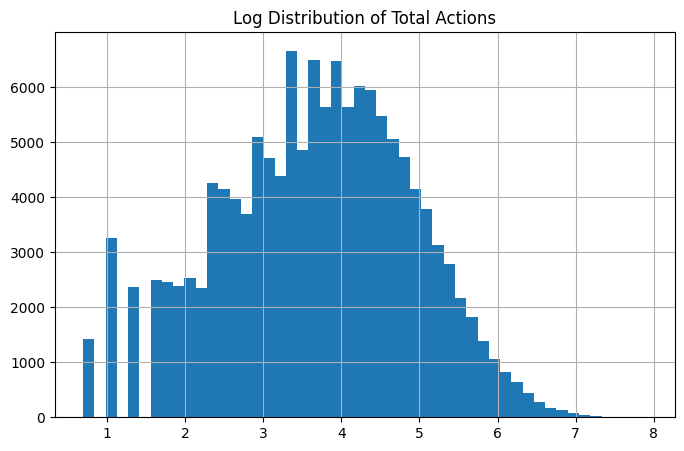

In [93]:
plt.figure(figsize=(8,5))
session_agg_v2["log_total_actions"].hist(bins=50)
plt.title("Log Distribution of Total Actions")
plt.show()


In [94]:
# =========================
# Merge data with Session Features
# =========================

data_merged = data.merge(
    session_agg_v2,
    how="left",
    left_on="id",
    right_on="user_id"
)

print(data_merged.shape)


(213451, 61)


In [95]:
# Check how many users have no sessions
no_session_ratio = data_merged["total_actions"].isna().mean()
print("Users without sessions ratio:", round(no_session_ratio, 4))


Users without sessions ratio: 0.6542


In [96]:
print("data columns:", data_merged.columns.tolist())

data columns: ['id', 'date_account_created', 'timestamp_first_active', 'date_first_booking', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination', 'dac_year', 'dac_month', 'dac_day', 'dac_weekday', 'tfa_year', 'tfa_month', 'tfa_day', 'user_id', 'total_actions', 'unique_actions', 'unique_action_types', 'unique_devices', 'total_secs', 'mean_secs', 'median_secs', 'std_secs', 'devices_list', 'actions_list', 'action_types_list', 'action_details_list', 'device_count__-unknown-', 'device_count__Android App Unknown Phone/Tablet', 'device_count__Android Phone', 'device_count__Chromebook', 'device_count__Linux Desktop', 'device_count__Mac Desktop', 'device_count__Tablet', 'device_count__Windows Desktop', 'device_count__iPad Tablet', 'device_count__iPhone', 'action_count__ajax_refresh_subtotal', 'action_count__index', 'action_count__personalize', 

In [97]:
pd.set_option('display.max_columns', None)

In [98]:
# session_agg_v2[['user_id','devices_list','actions_list']].head(3)
data_merged.head(5)

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination,dac_year,dac_month,dac_day,dac_weekday,tfa_year,tfa_month,tfa_day,user_id,total_actions,unique_actions,unique_action_types,unique_devices,total_secs,mean_secs,median_secs,std_secs,devices_list,actions_list,action_types_list,action_details_list,device_count__-unknown-,device_count__Android App Unknown Phone/Tablet,device_count__Android Phone,device_count__Chromebook,device_count__Linux Desktop,device_count__Mac Desktop,device_count__Tablet,device_count__Windows Desktop,device_count__iPad Tablet,device_count__iPhone,action_count__ajax_refresh_subtotal,action_count__index,action_count__personalize,action_count__reviews,action_count__search,action_count__search_results,action_count__show,action_count__similar_listings,action_count__social_connections,action_count__update,log_total_actions,log_total_secs,log_mean_secs,log_median_secs,log_std_secs
0,gxn3p5htnn,2010-06-28,2009-03-19 04:32:55,NaT,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF,2010,6,28,0,2009,3,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,820tgsjxq7,2011-05-25,2009-05-23 17:48:09,NaT,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF,2011,5,25,2,2009,5,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4ft3gnwmtx,2010-09-28,2009-06-09 23:12:47,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US,2010,9,28,1,2009,6,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bjjt8pjhuk,2011-12-05,2009-10-31 06:01:29,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other,2011,12,5,0,2009,10,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,87mebub9p4,2010-09-14,2009-12-08 06:11:05,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US,2010,9,14,1,2009,12,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Figure size 1200x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap')

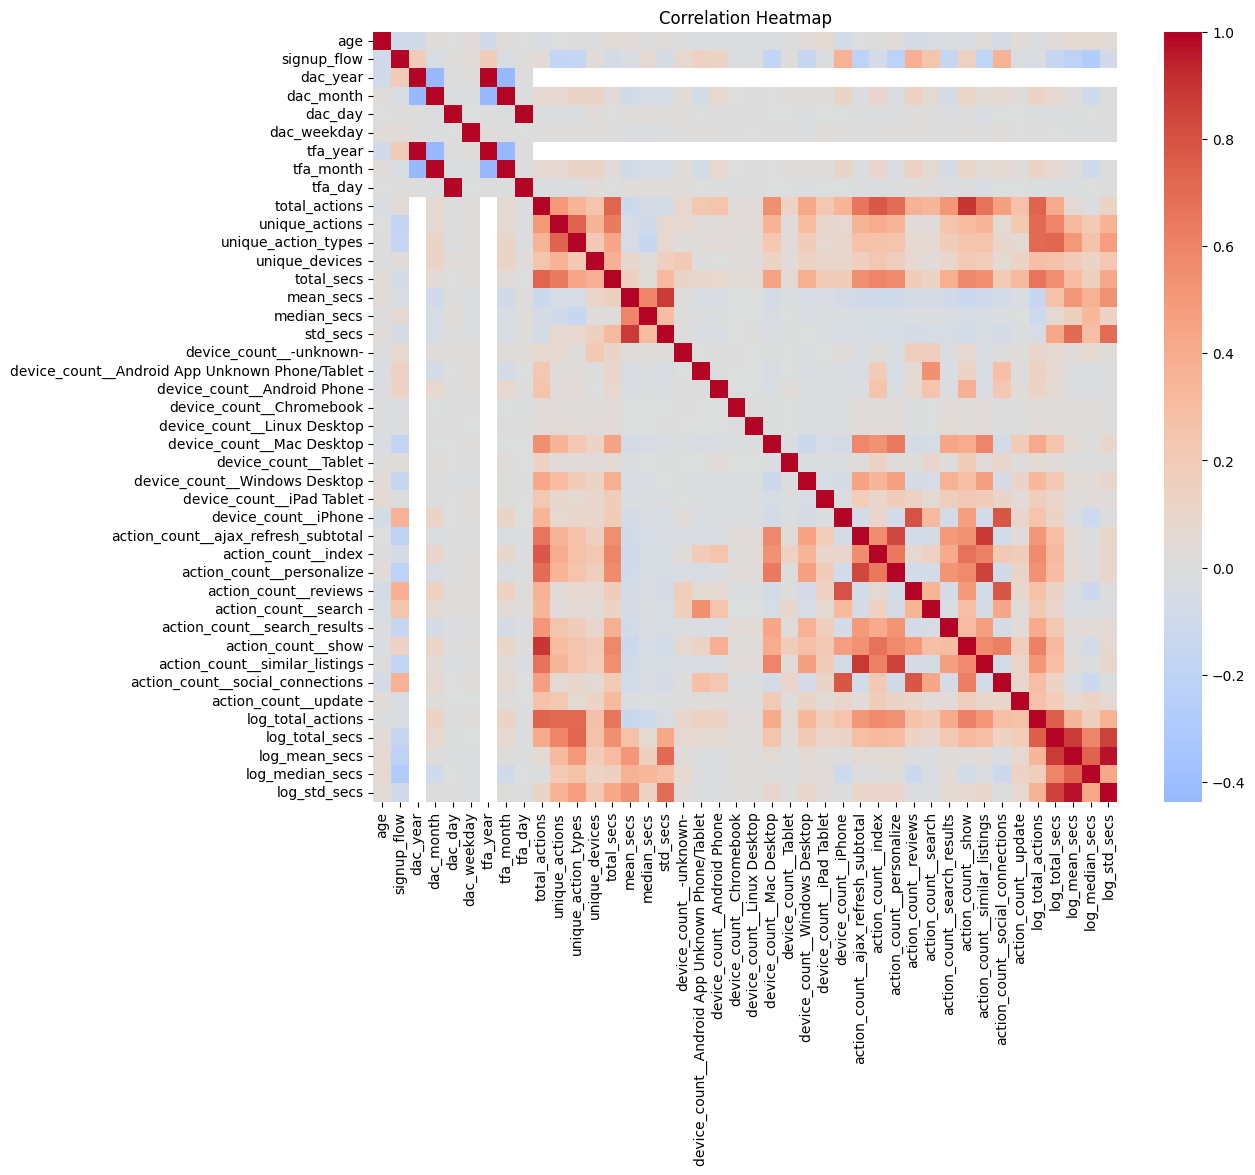

In [99]:
import seaborn as sns

numeric_cols = data_merged.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,10))
sns.heatmap(data_merged[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


<Figure size 1000x500 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Age Distribution')

Text(0.5, 0, 'Age')

Text(0, 0.5, 'Frequency')

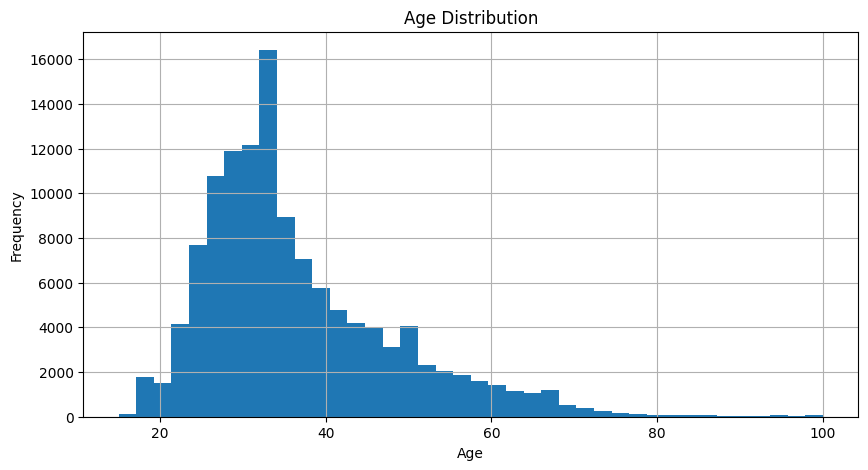

In [100]:
plt.figure(figsize=(10,5))
data_merged["age"].hist(bins=40)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


In [101]:
data_merged["age_bucket"] = pd.cut(
    data_merged["age"],
    bins=[0,25,35,45,55,65,120],
    labels=["<25","25-35","35-45","45-55","55-65","65+"]
)


In [102]:
session_numeric_cols = [
    "log_total_actions","log_total_secs",
    "log_mean_secs","log_median_secs","log_std_secs",
    "unique_actions","unique_action_types","unique_devices"
]

data_merged[session_numeric_cols] = data_merged[session_numeric_cols].fillna(0)


In [103]:
data_merged["actions_per_device"] = (
    data_merged["log_total_actions"] /
    (data_merged["unique_devices"] + 1)
)


In [104]:
print("Data columns:", len(data_merged.columns.tolist()))

Data columns: 63


In [105]:
# =========================
# Final Feature Selection
# =========================

cols_to_drop = [
    # identifiers
    "id",
    "user_id",
    
    # raw datetime columns
    "date_account_created",
    "timestamp_first_active",
    "date_first_booking",
    
    # raw session features (keep log versions only)
    "total_actions",
    "total_secs",
    "mean_secs",
    "median_secs",
    "std_secs",
    
    # list features
    "devices_list",
    "actions_list",
    "action_types_list",
    "action_details_list",
]

data_merged = data_merged.drop(columns=cols_to_drop)

print("New shape after cleaning:", data_merged.shape)
print("\nRemaining columns:")
print(data_merged.columns.tolist())


New shape after cleaning: (213451, 49)

Remaining columns:
['gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination', 'dac_year', 'dac_month', 'dac_day', 'dac_weekday', 'tfa_year', 'tfa_month', 'tfa_day', 'unique_actions', 'unique_action_types', 'unique_devices', 'device_count__-unknown-', 'device_count__Android App Unknown Phone/Tablet', 'device_count__Android Phone', 'device_count__Chromebook', 'device_count__Linux Desktop', 'device_count__Mac Desktop', 'device_count__Tablet', 'device_count__Windows Desktop', 'device_count__iPad Tablet', 'device_count__iPhone', 'action_count__ajax_refresh_subtotal', 'action_count__index', 'action_count__personalize', 'action_count__reviews', 'action_count__search', 'action_count__search_results', 'action_count__show', 'action_count__similar_listings', 'action_count__social_connections', 'action_count__upd

In [106]:
data_merged.dtypes.value_counts()

float64     30
object      10
int32        7
int64        1
category     1
Name: count, dtype: int64

In [176]:
print("Data columns:", data_merged.columns.tolist())

Data columns: ['gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'country_destination', 'dac_year', 'dac_month', 'dac_day', 'dac_weekday', 'tfa_year', 'tfa_month', 'tfa_day', 'unique_actions', 'unique_action_types', 'unique_devices', 'device_count__-unknown-', 'device_count__Android App Unknown Phone/Tablet', 'device_count__Android Phone', 'device_count__Chromebook', 'device_count__Linux Desktop', 'device_count__Mac Desktop', 'device_count__Tablet', 'device_count__Windows Desktop', 'device_count__iPad Tablet', 'device_count__iPhone', 'action_count__ajax_refresh_subtotal', 'action_count__index', 'action_count__personalize', 'action_count__reviews', 'action_count__search', 'action_count__search_results', 'action_count__show', 'action_count__similar_listings', 'action_count__social_connections', 'action_count__update', 'log_total_actions', 'log_total_secs', 

<Figure size 1200x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap')

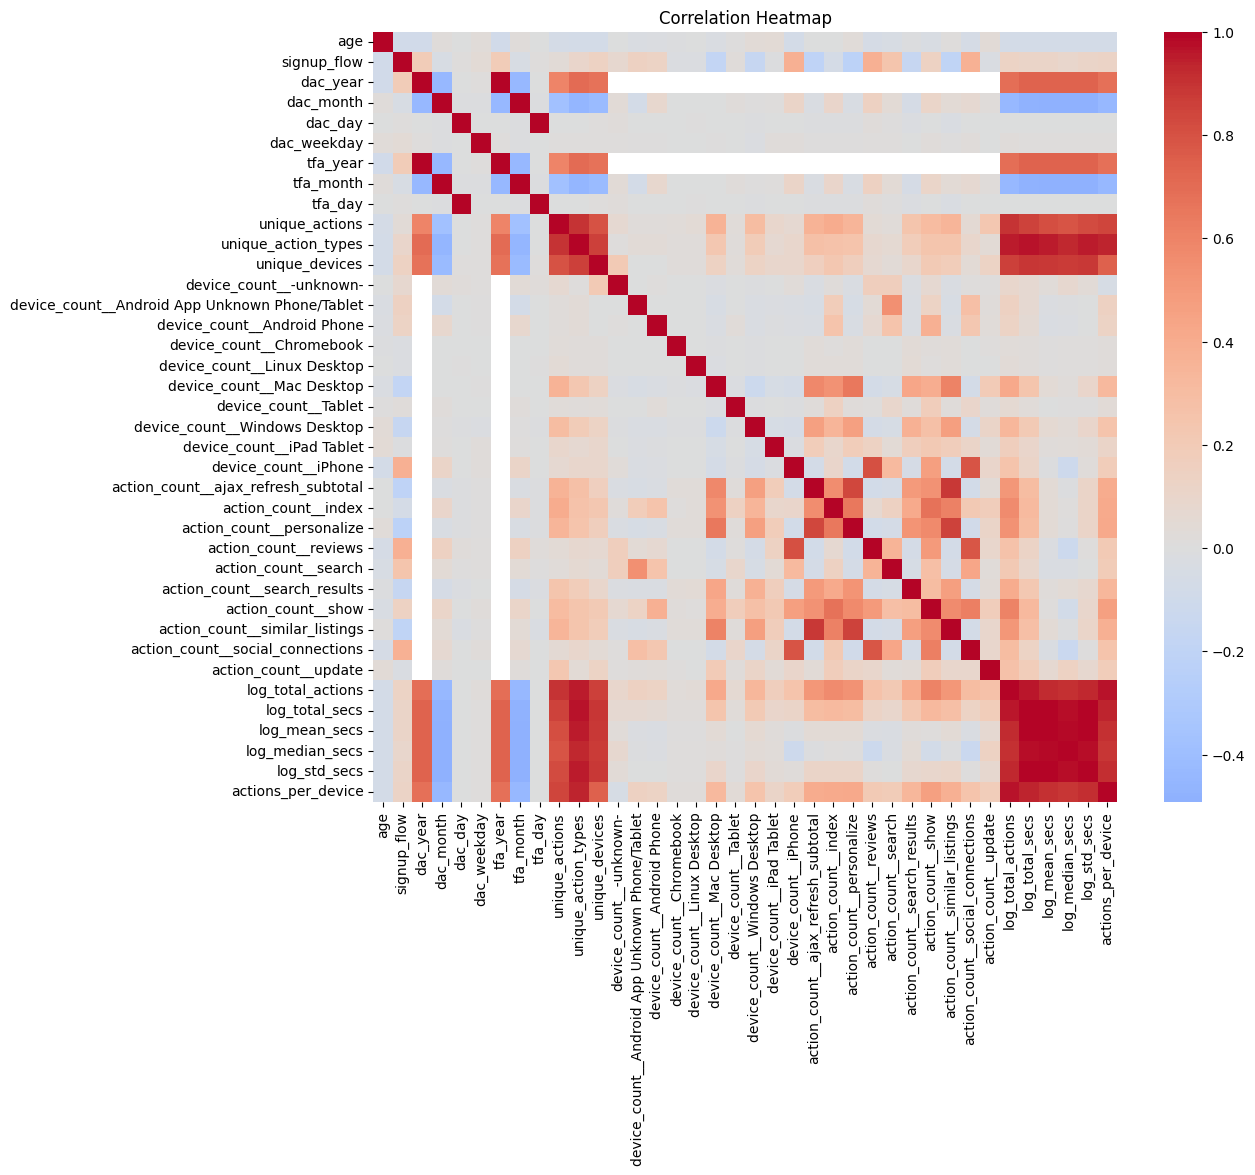

In [108]:
import seaborn as sns

numeric_cols = data_merged.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,10))
sns.heatmap(data_merged[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()
